<a href="https://colab.research.google.com/github/AjaySreekumar47/vlm-research/blob/main/Endo_Vis2018_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/EndoVis2018"

miccai_challenge_2018_release_1.zip  miccai_challenge_release_4.zip
miccai_challenge_release_2.zip	     repairs.zip
miccai_challenge_release_3.zip


In [3]:
import zipfile
import os

# Paths in Drive
drive_path = "/content/drive/MyDrive/EndoVis2018"
local_path = "/content/EndoVis2018"  # temporary workspace in Colab

os.makedirs(local_path, exist_ok=True)

# Loop through all zip files and extract them
for f in os.listdir(drive_path):
    if f.endswith(".zip"):
        zip_fp = os.path.join(drive_path, f)
        with zipfile.ZipFile(zip_fp, 'r') as zip_ref:
            zip_ref.extractall(local_path)

print("Extraction complete. Files now in:", local_path)

Extraction complete. Files now in: /content/EndoVis2018


## Top Level Structure

In [7]:
# !ls -R /content/EndoVis2018 | head -n 250

### 1. High-level folders

At `/content/EndoVis2018` you have:

* **`miccai_challenge_2018_release_1 … release_4`** → the four official dataset releases.
* **`repairs`** → patches/fixes for earlier releases (e.g., corrected labels).
* **`__MACOSX`** → a macOS artifact you can ignore. It just mirrors the folder names without data.

---

### 2. Inside a release

Example: `miccai_challenge_2018_release_1`

* **`labels.json`**
  A JSON file mapping **label IDs to semantic categories** (e.g., 1 = instrument shaft, 2 = jaws, 3 = wrist, etc.). This is the “ontology” for masks.

* **`seq_1`, `seq_2`, …**
  Each sequence corresponds to a **short surgical video**. Inside each sequence:

  * **`camera_calibration.txt`**
    Stereo calibration parameters for the left and right cameras (useful if you’re doing 3D reconstruction).

  * **`left_frames/`**
    Raw RGB images from the **left stereo camera** (`frame000.png`, …).
    Each frame = one timestep of the video.

  * **`right_frames/`**
    Same as above, but from the **right stereo camera**.

  * **`labels/`**
    Segmentation masks aligned 1-to-1 with `left_frames`.
    Each pixel value is an integer that maps to a class in `labels.json`.

---

### 3. Example: `seq_1`

From your snippet:

* `left_frames/frame000.png` ↔ `labels/frame000.png`
  Together, this means: the original surgical frame and its pixelwise semantic segmentation.

* You saw frames `frame000.png` through at least `frame148.png` in `labels/`.
  So sequence 1 has **\~150 annotated frames**.

---

### 4. Other releases (2, 3, 4)

They follow the **same structure**:

* `seq_N` folders with `left_frames`, `right_frames`, `labels`, and calibration files.
* Each release adds more sequences to broaden dataset coverage.

---

### 5. What each file represents

* **RGB frames (`left_frames`, `right_frames`)**: Visual input from stereo laparoscopic cameras.
* **Segmentation masks (`labels`)**: Ground truth for semantic segmentation.
* **`labels.json`**: The dictionary of class IDs → surgical structures (instruments, tissue types, suturing thread, etc.).
* **Calibration (`camera_calibration.txt`)**: Intrinsics/extrinsics for 3D stereo geometry.
* **Repairs folder**: Contains corrected versions of masks/frames for quality control.

---

### 6. Usage for SEEM (or any segmentation model)

* **Inputs**: `left_frames/*.png`
* **Targets**: `labels/*.png` (convert pixel IDs to categories using `labels.json`)
* **Optional**: Use `right_frames` for stereo-based tasks or `camera_calibration.txt` for geometry.


✅ You now have a **complete mental model**:
EndoVis2018 = *four releases of short annotated stereo video sequences*, each containing raw frames, semantic segmentation labels, and calibration data, plus a label ontology.

## Inspecting files extracted

In [9]:
import json

labels_json_path = "/content/EndoVis2018/miccai_challenge_2018_release_1/labels.json"

with open(labels_json_path, 'r') as f:
    labels_list = json.load(f)

print("Number of classes:", len(labels_list))
print("Classes mapping:")
for idx, label in enumerate(labels_list):
    print(f"{idx}: {label}")

Number of classes: 11
Classes mapping:
0: {'name': 'background-tissue', 'color': [0, 0, 0], 'classid': 0}
1: {'name': 'instrument-shaft', 'color': [0, 255, 0], 'classid': 1}
2: {'name': 'instrument-clasper', 'color': [0, 255, 255], 'classid': 2}
3: {'name': 'instrument-wrist', 'color': [125, 255, 12], 'classid': 3}
4: {'name': 'kidney-parenchyma', 'color': [255, 55, 0], 'classid': 4}
5: {'name': 'covered-kidney', 'color': [24, 55, 125], 'classid': 5}
6: {'name': 'thread', 'color': [187, 155, 25], 'classid': 6}
7: {'name': 'clamps', 'color': [0, 255, 125], 'classid': 7}
8: {'name': 'suturing-needle', 'color': [255, 255, 125], 'classid': 8}
9: {'name': 'suction-instrument', 'color': [123, 15, 175], 'classid': 9}
10: {'name': 'small-intestine', 'color': [124, 155, 5], 'classid': 10}


## 🔹 The 11 Classes in EndoVis2018

| ID | Name               | Meaning in context                                                                  | Color (for visualization)        |
| -- | ------------------ | ----------------------------------------------------------------------------------- | -------------------------------- |
| 0  | background-tissue  | Everything that isn’t specifically annotated (abdominal cavity, fat, vessels, etc.) | `[0, 0, 0]` (black)              |
| 1  | instrument-shaft   | Long cylindrical shaft of robotic instruments                                       | `[0, 255, 0]` (green)            |
| 2  | instrument-clasper | The two jaws (“grasper” or “clasper”) that hold/manipulate tissue                   | `[0, 255, 255]` (cyan)           |
| 3  | instrument-wrist   | The articulated wrist part (near the end effector)                                  | `[125, 255, 12]` (lime)          |
| 4  | kidney-parenchyma  | The kidney tissue being operated on                                                 | `[255, 55, 0]` (red-orange)      |
| 5  | covered-kidney     | Regions of kidney that are occluded/covered                                         | `[24, 55, 125]` (dark blue)      |
| 6  | thread             | Suturing thread                                                                     | `[187, 155, 25]` (golden)        |
| 7  | clamps             | Surgical clips/clamps                                                               | `[0, 255, 125]` (mint green)     |
| 8  | suturing-needle    | Needle used for suturing                                                            | `[255, 255, 125]` (light yellow) |
| 9  | suction-instrument | Suction/aspiration tool                                                             | `[123, 15, 175]` (purple)        |
| 10 | small-intestine    | Adjacent anatomical structure (small bowel)                                         | `[124, 155, 5]` (olive)          |

---

### 🧩 Observations:

* **Classes 1–3**: Sub-parts of surgical instruments. This granularity helps in tracking and fine-grained segmentation (shaft vs wrist vs jaws).
* **Classes 4–5**: Organ of interest (kidney), both visible and occluded.
* **Classes 6–8**: Tools for suturing (thread, clamps, needle).
* **Class 9**: Accessory instrument (suction).
* **Class 10**: Surrounding anatomy (intestine).

---

👉 So now we know **exactly what the masks represent**: each pixel’s value (0–10) maps to one of these categories.

Unique classes in mask: [  0 109 150 179]


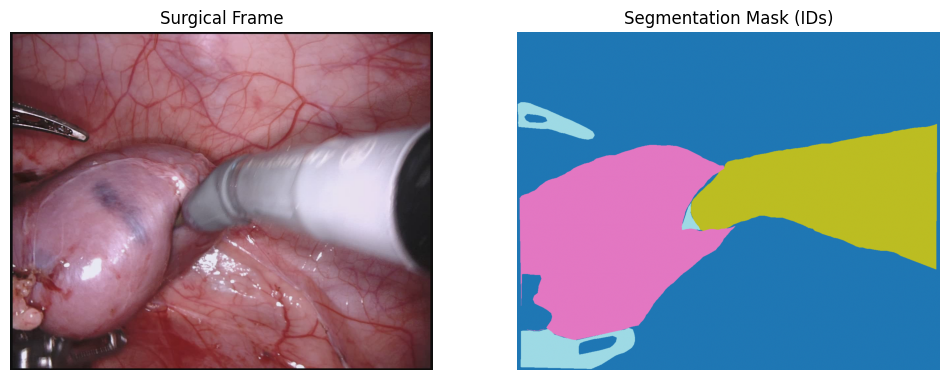

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Pick one sequence and frame
frame_id = "frame000.png"
frame_path = "/content/EndoVis2018/miccai_challenge_2018_release_1/seq_1/left_frames/" + frame_id
mask_path  = "/content/EndoVis2018/miccai_challenge_2018_release_1/seq_1/labels/" + frame_id

# Load RGB frame
frame = np.array(Image.open(frame_path))

# Load segmentation mask (mode 'L' ensures integer labels)
mask = np.array(Image.open(mask_path).convert("L"))

# Unique values in mask = class IDs present in this frame
print("Unique classes in mask:", np.unique(mask))

# Show side by side
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(frame)
plt.title("Surgical Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab20")  # colormap for categorical masks
plt.title("Segmentation Mask (IDs)")
plt.axis("off")

plt.show()

Unique colors in mask: [[  0   0   0]
 [  0 255   0]
 [  0 255 255]
 [255  55   0]]
Unique class IDs in this mask: [0 1 2 4]


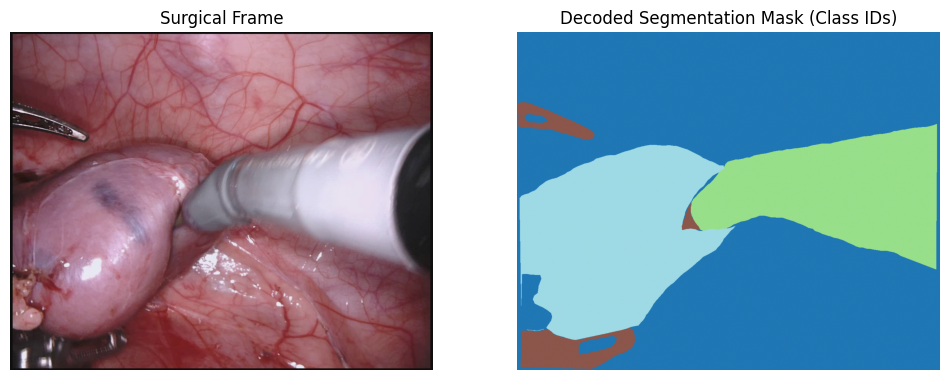

In [11]:
# Load in RGB mode
mask_rgb = np.array(Image.open(mask_path).convert("RGB"))

# Get unique colors in the mask
unique_colors = np.unique(mask_rgb.reshape(-1, 3), axis=0)
print("Unique colors in mask:", unique_colors)

# Build color → classid mapping from labels.json
color_to_class = {tuple(lbl["color"]): lbl["classid"] for lbl in labels_list}

# Translate mask colors to class IDs
mask_ids = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
for color, classid in color_to_class.items():
    matches = np.all(mask_rgb == np.array(color), axis=-1)
    mask_ids[matches] = classid

print("Unique class IDs in this mask:", np.unique(mask_ids))

# Show overlay
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(frame)
plt.title("Surgical Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_ids, cmap="tab20")
plt.title("Decoded Segmentation Mask (Class IDs)")
plt.axis("off")

plt.show()

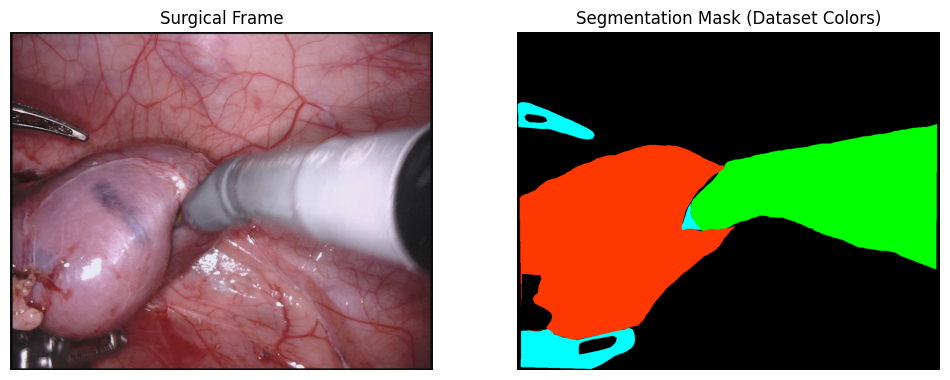

In [13]:
# Build classid -> RGB colormap from labels.json
id_to_color = {lbl["classid"]: lbl["color"] for lbl in labels_list}

# Convert mask_ids to RGB using official colors
mask_rgb_vis = np.zeros((*mask_ids.shape, 3), dtype=np.uint8)
for classid, color in id_to_color.items():
    mask_rgb_vis[mask_ids == classid] = color

# Show with dataset’s official colors
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(frame)
plt.title("Surgical Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_rgb_vis)
plt.title("Segmentation Mask (Dataset Colors)")
plt.axis("off")

plt.show()

## 🔹 Interpretation of the sample frame

The unique colors you found:

```
[0, 0, 0]   → background-tissue  (ID 0)
[0, 255, 0] → instrument-shaft   (ID 1)
[0, 255, 255] → instrument-clasper (ID 2)
[255, 55, 0] → kidney-parenchyma (ID 4)
```

So in this frame we see:

* **Background tissue** (abdominal cavity etc.)
* **Shaft of a robotic instrument**
* **Clasper/jaws of the instrument** (the part gripping/manipulating)
* **Kidney parenchyma** (the organ being operated on)

And if you look at your visualization:

* The pink-ish region → **kidney**
* The green-ish long cylinder → **instrument shaft**
* The cyan tips → **instrument clasper**
* Everything else (dark background) → **background tissue**

---

## 🔑 What we’ve established so far

1. **`labels.json`** defines 11 semantic categories.
2. **Masks are stored as RGB images**, where pixel colors encode categories.
3. We can decode them into class IDs 0–10 for training.
4. Each frame has a paired **RGB input** (`left_frames`) and **mask output** (`labels`).

## Checking visualizations of all 4 releases

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Build global classid → RGB color mapping from labels.json (we'll load per release if needed)
def load_label_map(labels_json_path):
    import json
    with open(labels_json_path, 'r') as f:
        labels_list = json.load(f)
    id_to_color = {lbl["classid"]: tuple(lbl["color"]) for lbl in labels_list}
    id_to_name  = {lbl["classid"]: lbl["name"] for lbl in labels_list}
    return id_to_color, id_to_name

# Load one frame + mask, and render with dataset colors
def visualize_frame_mask(release, seq, frame_id="frame000.png"):
    """
    release: str, e.g. "miccai_challenge_2018_release_1"
    seq: str, e.g. "seq_1"
    frame_id: str, e.g. "frame000.png"
    """
    base = f"/content/EndoVis2018/{release}/{seq}"

    # Paths
    frame_path = os.path.join(base, "left_frames", frame_id)
    mask_path  = os.path.join(base, "labels", frame_id)
    labels_json_path = os.path.join(f"/content/EndoVis2018/{release}", "labels.json")

    # Load mappings
    id_to_color, id_to_name = load_label_map(labels_json_path)

    # Load images
    frame = np.array(Image.open(frame_path))
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))

    # Decode mask: map RGB → classid
    mask_ids = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
    for classid, color in id_to_color.items():
        matches = np.all(mask_rgb == np.array(color), axis=-1)
        mask_ids[matches] = classid

    # Build mask visualization using official colors
    mask_vis = np.zeros((*mask_ids.shape, 3), dtype=np.uint8)
    for classid, color in id_to_color.items():
        mask_vis[mask_ids == classid] = color

    # Unique classes in this mask
    unique_classes = np.unique(mask_ids)
    class_names = [id_to_name[cid] for cid in unique_classes]

    # Plot
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(frame)
    # plt.title(f"{release} | {seq} | {frame_id}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_vis)
    plt.title(f"Segmentation Mask:\n {class_names}")
    plt.axis("off")

    plt.show()

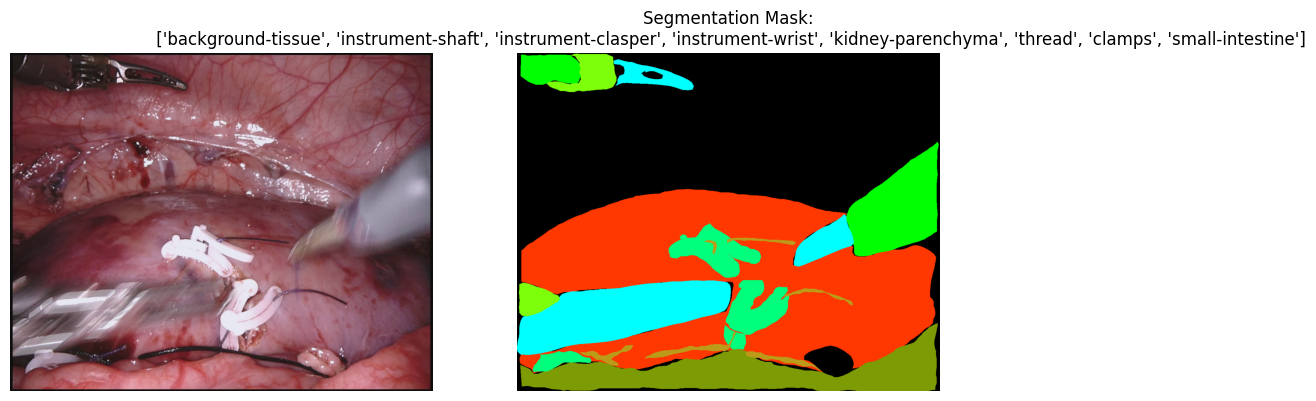

In [28]:
visualize_frame_mask("miccai_challenge_2018_release_1", "seq_1", "frame005.png")

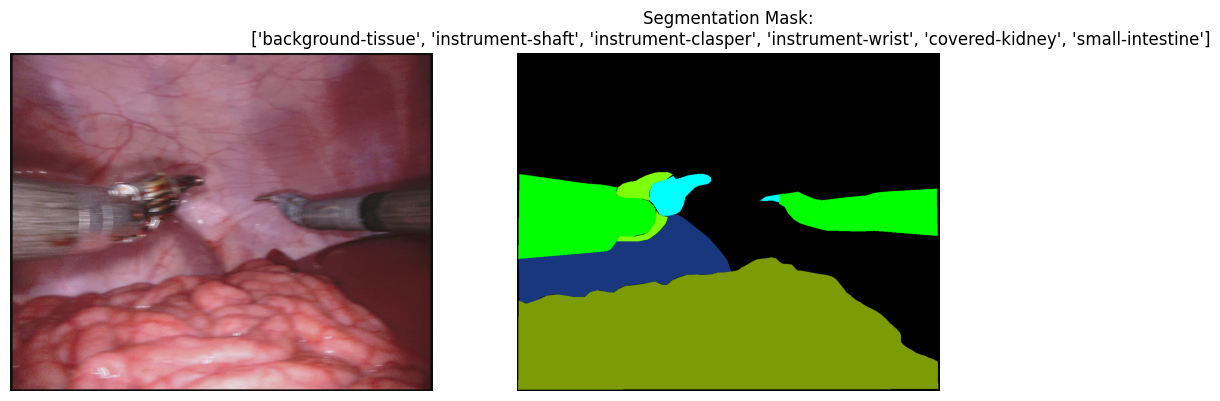

In [33]:
visualize_frame_mask("miccai_challenge_release_2", "seq_6", "frame005.png")

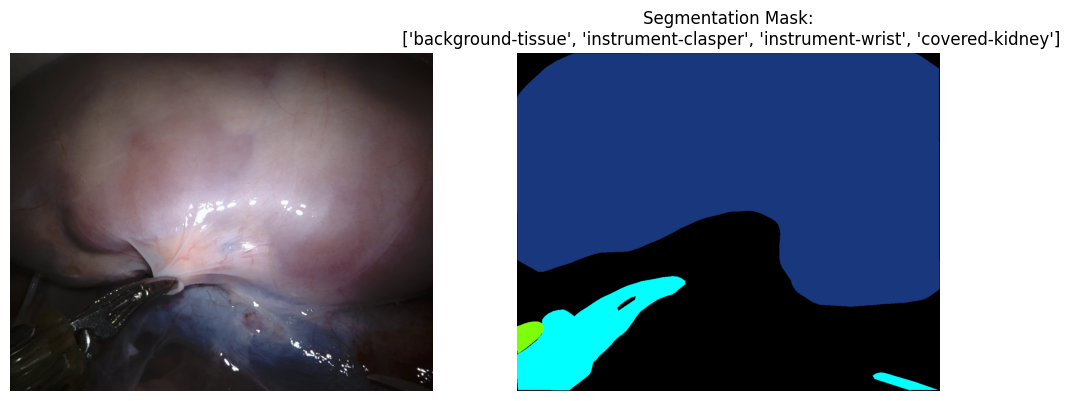

In [35]:
visualize_frame_mask("miccai_challenge_release_3", "seq_10", "frame005.png")

In [37]:
def load_label_map(labels_json_path):
    import json
    if not os.path.exists(labels_json_path):
        # Fallback to release_1 labels.json
        labels_json_path = "/content/EndoVis2018/miccai_challenge_2018_release_1/labels.json"
    with open(labels_json_path, 'r') as f:
        labels_list = json.load(f)
    id_to_color = {lbl["classid"]: tuple(lbl["color"]) for lbl in labels_list}
    id_to_name  = {lbl["classid"]: lbl["name"] for lbl in labels_list}
    return id_to_color, id_to_name

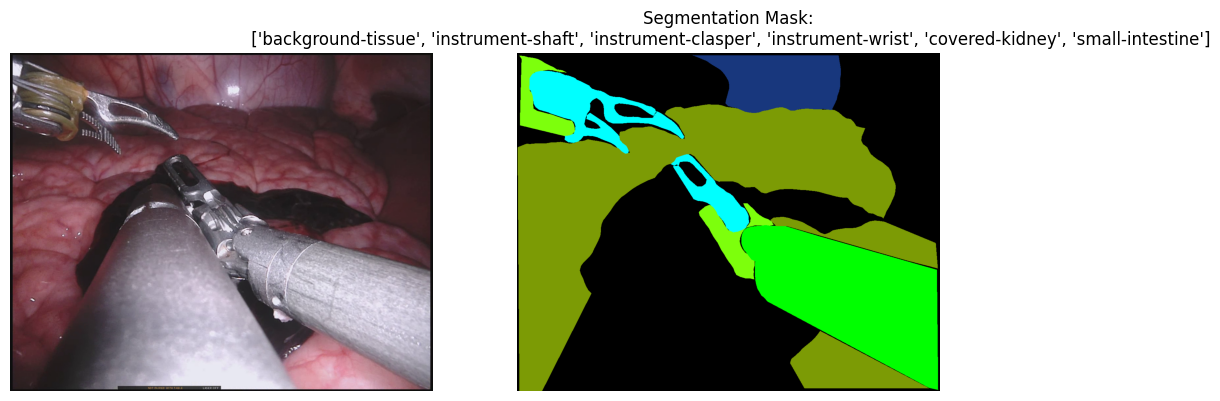

In [38]:
visualize_frame_mask("miccai_challenge_release_4", "seq_14", "frame005.png")

## Dataset Summary

In [44]:
import os
import numpy as np
from PIL import Image
import json

# Load the ontology (always from release_1)
with open("/content/EndoVis2018/miccai_challenge_2018_release_1/labels.json", "r") as f:
    labels_list = json.load(f)
id_to_name = {lbl["classid"]: lbl["name"] for lbl in labels_list}
color_to_class = {tuple(lbl["color"]): lbl["classid"] for lbl in labels_list}

def decode_mask(mask_path):
    """Return unique class IDs from an RGB mask"""
    mask_rgb = np.array(Image.open(mask_path).convert("RGB"))
    unique_colors = np.unique(mask_rgb.reshape(-1, 3), axis=0)
    class_ids = set()
    for color in map(tuple, unique_colors):
        if color in color_to_class:
            class_ids.add(color_to_class[color])
    return sorted(class_ids)

valid_exts = {".png", ".jpg", ".jpeg"}

def summarize_release(release):
    release_path = os.path.join("/content/EndoVis2018", release)
    seqs = [d for d in os.listdir(release_path) if d.startswith("seq")]
    print(f"\n=== {release} ===")
    for seq in sorted(seqs):
        seq_path = os.path.join(release_path, seq)
        left_dir = os.path.join(seq_path, "left_frames")
        labels_dir = os.path.join(seq_path, "labels")

        # Count frames
        frames = sorted([f for f in os.listdir(left_dir) if os.path.splitext(f)[1].lower() in valid_exts])
        n_frames = len(frames)

        # Collect unique classes from all masks
        unique_classes = set()
        for fname in frames:
            mask_path = os.path.join(labels_dir, fname)
            if os.path.exists(mask_path) and os.path.splitext(fname)[1].lower() in valid_exts:
                unique_classes.update(decode_mask(mask_path))

        class_names = [id_to_name[cid] for cid in sorted(unique_classes)]
        print(f"{seq}: {n_frames} frames | Classes: {class_names}")

# Run for all four releases
for release in [
    # "miccai_challenge_2018_release_1",
    # "miccai_challenge_release_2",
    # "miccai_challenge_release_3",
    # "miccai_challenge_release_4"
]:
    summarize_release(release)

Stats:
```
=== miccai_challenge_2018_release_1 ===
seq_1: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'kidney-parenchyma', 'thread', 'clamps', 'suturing-needle', 'suction-instrument', 'small-intestine']
seq_2: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'kidney-parenchyma', 'thread', 'clamps', 'small-intestine']
seq_3: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'kidney-parenchyma', 'covered-kidney', 'suction-instrument', 'small-intestine']
=== miccai_challenge_release_2 ===
seq_5: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'kidney-parenchyma', 'thread', 'clamps', 'suction-instrument']
=== miccai_challenge_release_3 ===
seq_10: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'kidney-parenchyma', 'covered-kidney']
=== miccai_challenge_release_4 ===
seq_13: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'covered-kidney', 'small-intestine']
seq_14: 149 frames | Classes: ['background-tissue', 'instrument-shaft', 'instrument-clasper', 'instrument-wrist', 'covered-kidney', 'small-intestine']
```

## 📊 EndoVis2018 Dataset Summary (based on stats)

### 🔹 Release 1 (seq\_1–seq\_3)

* **Frames per sequence**: \~149
* **Class coverage**:

  * `seq_1`: almost all classes → background, all instrument parts, kidney, clamps, thread, suturing needle, suction, intestine.
  * `seq_2`: clamps + thread, but no covered kidney, suction, needle.
  * `seq_3`: has covered kidney + suction, but no needle, clamps.
* **Insight**: This release gives the **richest class variety**, especially suturing-related classes (`needle`, `thread`).

---

### 🔹 Release 2 (seq\_5)

* **Frames**: \~149
* **Classes**: background, all instrument parts, kidney, clamps, thread, suction.
* **Missing**: suturing needle, covered kidney, intestine.
* **Insight**: Strong on instrument + accessory tools, but no needle/intestine.

---

### 🔹 Release 3 (seq\_10)

* **Frames**: \~149
* **Classes**: background, all instrument parts, kidney, covered kidney.
* **Missing**: clamps, thread, suction, needle, intestine.
* **Insight**: Narrower — mostly instrument + organ, with covered kidney.

---

### 🔹 Release 4 (seq\_13, seq\_14)

* **Frames**: \~149 each
* **Classes**: background, all instrument parts, covered kidney, intestine.
* **Missing**: clamps, thread, suction, needle.
* **Insight**: Narrow scope — focuses on instrument + covered kidney + intestine.

---

## 🧩 Overall Insights

1. **Common classes** (always present across releases):

   * `background-tissue`
   * `instrument-shaft`, `instrument-clasper`, `instrument-wrist`
   * `kidney-parenchyma`

2. **Occasional classes** (appear in some sequences/releases):

   * `covered-kidney` → Release 1, Release 3, Release 4
   * `small-intestine` → Release 1, Release 4

3. **Rare classes** (critical for evaluation, but limited availability):

   * `suturing-needle` → Only in Release 1 (seq\_1).
   * `thread` → Release 1 (seq\_1, seq\_2), Release 2 (seq\_5).
   * `clamps` → Release 1 (seq\_1, seq\_2), Release 2 (seq\_5).
   * `suction-instrument` → Release 1 (seq\_1, seq\_3), Release 2 (seq\_5).

---

## ✅ What This Means SEEM

* **Release 1** is your *go-to* for full ontology coverage (esp. suturing).
* **Release 2** helps reinforce clamps/thread/suction.
* **Release 3 + 4** are narrower — good for testing generalization on simpler class subsets.
* You may want to **balance your splits**: if you only train on Release 1, the model might overfit to suturing but underperform on simpler scenes.


In [45]:
import os

repairs_path = "/content/EndoVis2018/repairs"
for root, dirs, files in os.walk(repairs_path):
    print(root, "->", len(files), "files")
    for f in sorted(files)[:10]:  # print first 10 files for preview
        print("   ", f)

/content/EndoVis2018/repairs -> 7 files
    seq_1_frame042.png
    seq_1_frame043.png
    seq_1_frame044.png
    seq_1_frame073.png
    seq_4_frame135.png
    seq_4_frame137.png
    seq_4_frame138.png


In [46]:
def visualize_repair(frame_id):
    """
    frame_id: filename inside repairs folder, e.g. 'frame010.png'
    """
    repair_path = os.path.join(repairs_path, frame_id)

    # Load as RGB
    mask_rgb = np.array(Image.open(repair_path).convert("RGB"))

    # Decode mask to class IDs
    mask_ids = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
    for classid, color in color_to_class.items():
        matches = np.all(mask_rgb == np.array(color), axis=-1)
        mask_ids[matches] = classid

    # Build dataset-color visualization
    mask_vis = np.zeros((*mask_ids.shape, 3), dtype=np.uint8)
    for classid, color in id_to_name.keys():
        mask_vis[mask_ids == classid] = color_to_class[classid]

    plt.figure(figsize=(6,6))
    plt.imshow(mask_vis)
    plt.title(f"Repair Mask: {frame_id}")
    plt.axis("off")
    plt.show()

    print("Unique class IDs in repaired mask:", np.unique(mask_ids))

In [50]:
def compare_repair_mask(seq, frame_id, release="miccai_challenge_2018_release_1"):
    """
    Compare original vs repaired segmentation masks with dataset colors.
    """
    import os
    from PIL import Image
    import numpy as np
    import matplotlib.pyplot as plt

    # Paths
    orig_path = f"/content/EndoVis2018/{release}/{seq}/labels/{frame_id}"
    repair_path = f"/content/EndoVis2018/repairs/{seq}_{frame_id}"

    # Load as RGB
    orig_rgb = np.array(Image.open(orig_path).convert("RGB"))
    repair_rgb = np.array(Image.open(repair_path).convert("RGB"))

    # Decode mask into class IDs
    def rgb_to_ids(mask_rgb):
        mask_ids = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
        for color, classid in color_to_class.items():  # color_to_class is { (R,G,B): id }
            matches = np.all(mask_rgb == np.array(color), axis=-1)
            mask_ids[matches] = classid
        return mask_ids

    # Map class IDs back to dataset colors
    def ids_to_colors(mask_ids):
        mask_vis = np.zeros((*mask_ids.shape, 3), dtype=np.uint8)
        for classid, color in id_to_color.items():
            mask_vis[mask_ids == classid] = color
        return mask_vis

    # Decode both
    orig_ids = rgb_to_ids(orig_rgb)
    repair_ids = rgb_to_ids(repair_rgb)
    orig_vis = ids_to_colors(orig_ids)
    repair_vis = ids_to_colors(repair_ids)

    # Unique classes
    orig_classes = np.unique(orig_ids)
    repair_classes = np.unique(repair_ids)

    # Plot
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(orig_vis)
    plt.title(f"Original: {seq}/{frame_id}\nClasses: {orig_classes}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(repair_vis)
    plt.title(f"Repaired: {seq}/{frame_id}\nClasses: {repair_classes}")
    plt.axis("off")

    plt.show()

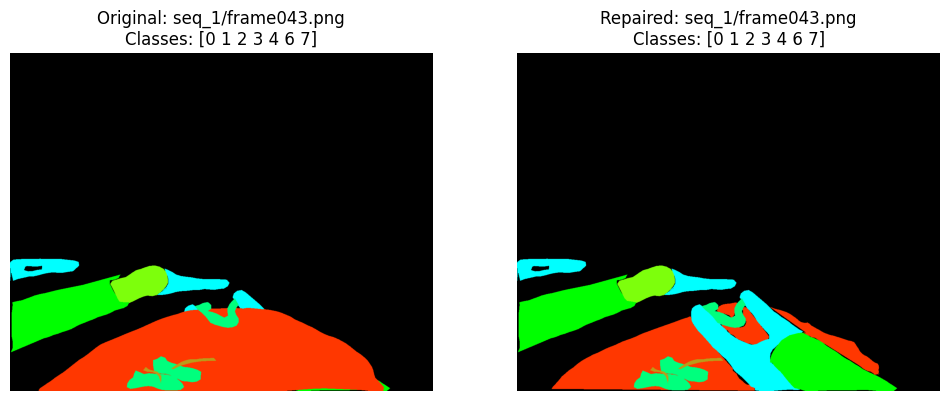

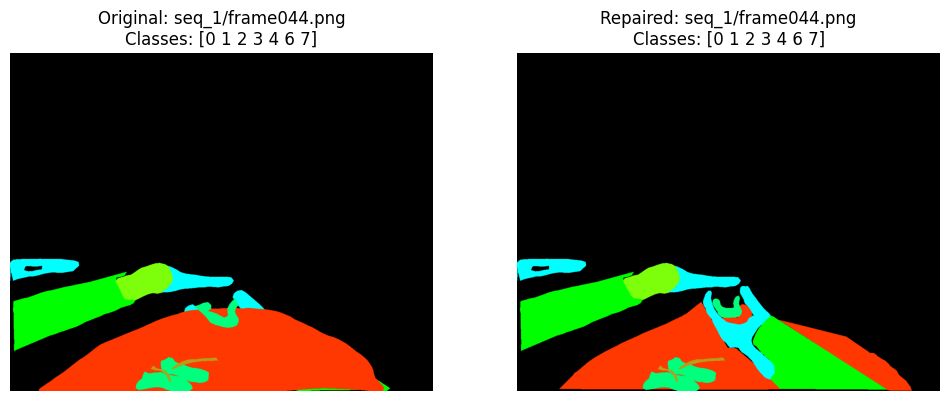

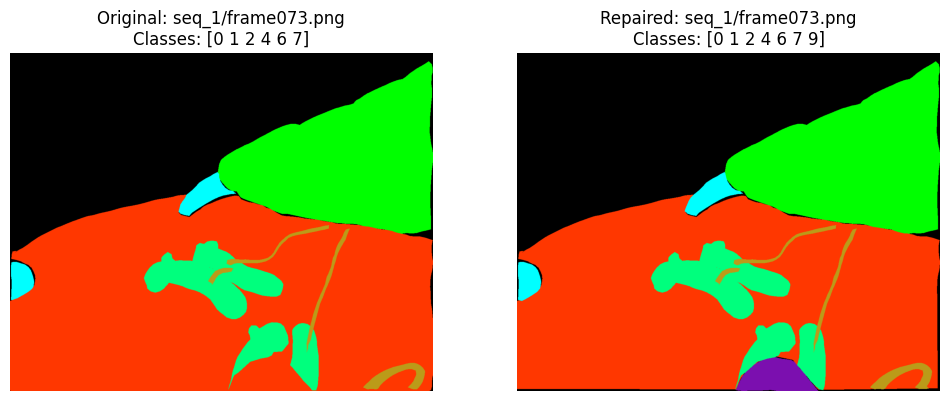

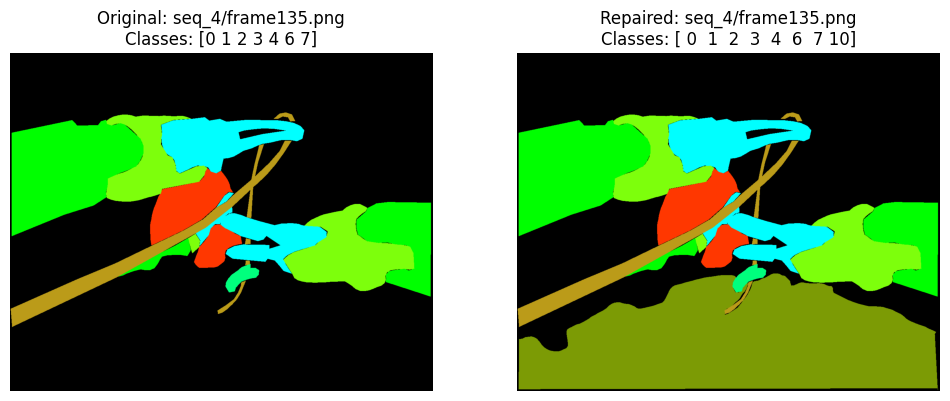

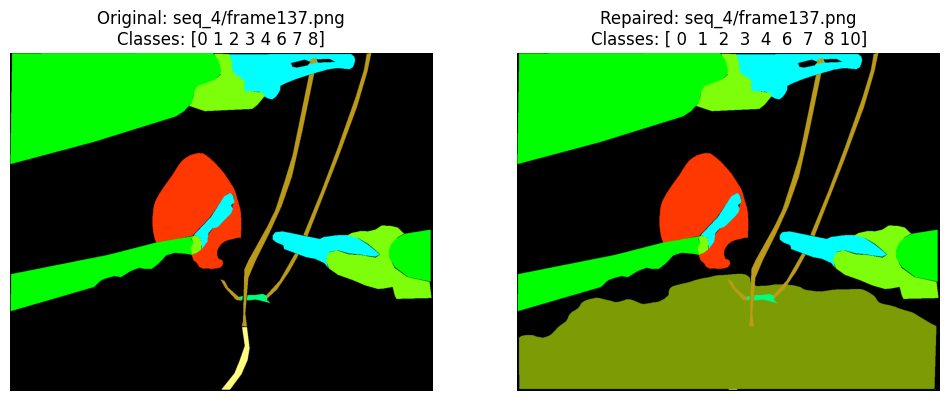

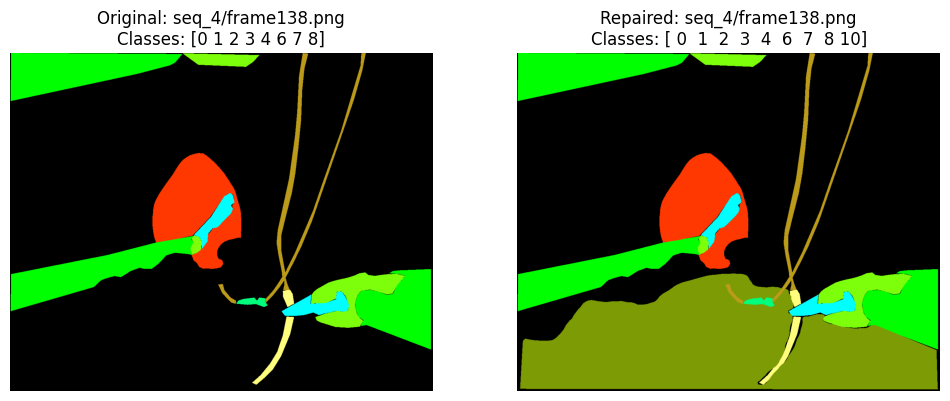

In [52]:
compare_repair_mask("seq_1", "frame043.png")
compare_repair_mask("seq_1", "frame044.png")
compare_repair_mask("seq_1", "frame073.png")
compare_repair_mask("seq_4", "frame135.png")
compare_repair_mask("seq_4", "frame137.png")
compare_repair_mask("seq_4", "frame138.png")